# 📊 KoCulture-Dialogues 탐색적 데이터 분석 (EDA)

학습에 들어가기 전에 데이터의 특성을 직접 확인합니다. 이 분석은 README **II장**에 들어가며,
특히 `max_seq_length=512` 같은 하이퍼파라미터 선택의 **근거**가 됩니다.

**분석 항목**
1. 기본 통계 (총 행 수, 고유 신조어 수)
2. 신조어별 예시 수 분포 → `images/eda_examples_per_slang.png`
3. 토큰 길이 분포 → `images/eda_token_length.png` (→ `max_seq_length` 근거)


In [1]:
# (Colab) 필요한 라이브러리 설치
!pip install -q -U datasets==3.0.0 transformers==4.46.0 matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 804.7 kB/s eta 0:00:00
Reason for being yanked: This version unfortunately does not work with 3.8 but we did not drop the support yet
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.3/474.3 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 63.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which i

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from datasets.builder import VerificationMode
from transformers import AutoTokenizer

os.makedirs('images', exist_ok=True)
MODEL_ID = 'Qwen/Qwen2.5-3B-Instruct'

## 1. 데이터 로드 & 기본 통계

In [4]:
ds_raw = load_dataset(
    'huggingface-KREW/KoCulture-Dialogues',
    split='train',
    verification_mode=VerificationMode.NO_CHECKS,
)

df = ds_raw.to_pandas()
print(f'총 행 수      : {len(df):,}')
print(f'고유 신조어 수 : {df["title"].nunique():,}')
print(f'필드          : {list(df.columns)}')
df.head(3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.28M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3456 [00:00<?, ? examples/s]

총 행 수      : 10,356
고유 신조어 수 : 354
필드          : ['title', 'question', 'answer']


,title,question,answer
0,추구미,ㅋㅋㅋ 지수야 인스타 스토리 봤는데 또 카페 투어했네?,ㅇㅇ ㅋㅋㅋ 조용한 동네에 작은 로스터리 카페 사장님이 되는 게 내 추구미라... ...
1,추구미,야 넌 진짜 아무리 술 마셔도 필기 다 하고 수업 다 들어가더라 대단하다 ㄹㅇ,"뭔소리야 ㅋㅋㅋㅋ 그냥 내 추구미가 놀때는 놀더라도 학점관리 철저한 대학생인데, 현..."
2,추구미,요즘 퇴근하고 뭐해? 갑자기 젤네일 하고 옷 스타일도 바뀌고 무슨일이야,그냥 이제 좀 꾸미면서 살려고...ㅎㅎ 프렌치 감성 오피스룩이 내 추구미인데 요즘 ...


## 2. 신조어별 예시 수 분포

평균만 보면 약 29개지만, 분포가 균등한지 롱테일인지가 학습 난이도에 영향을 줍니다.

In [5]:
counts = df['title'].value_counts()

print('=== 신조어별 예시 수 요약 ===')
print(f'평균   : {counts.mean():.1f}')
print(f'중앙값 : {counts.median():.0f}')
print(f'최대   : {counts.max()}  ({counts.idxmax()})')
print(f'최소   : {counts.min()}  ({counts.idxmin()})')

print('\n=== 예시 많은 신조어 TOP 10 ===')
print(counts.head(10).to_string())
print('\n=== 예시 적은 신조어 BOTTOM 10 ===')
print(counts.tail(10).to_string())

=== 신조어별 예시 수 요약 ===
평균   : 29.3
중앙값 : 30
최대   : 36  (0고백 1차임)
최소   : 5  (솔의눈 백 개 마셨다)

=== 예시 많은 신조어 TOP 10 ===
title
0고백 1차임      36
YOLO         36
깨알같다         36
어마무시하다       36
SEXY FOOD    35
엥 감전당했나      33
사건이다         31
처돌이          30
잼얘           30
우울핑          30

=== 예시 적은 신조어 BOTTOM 10 ===
title
선(先)학개미                      15
외계인 침공 시 ~한 사람이 먼저 잡아먹힌다     10
불매합니다                        10
국민 OO                        10
갓                            10
선학개미                         10
불매합니다.                       10
외계인 침공 시 ~한 사람이 먼저 잡아먹힌다.    10
망붕                            9
솔의눈 백 개 마셨다                   5


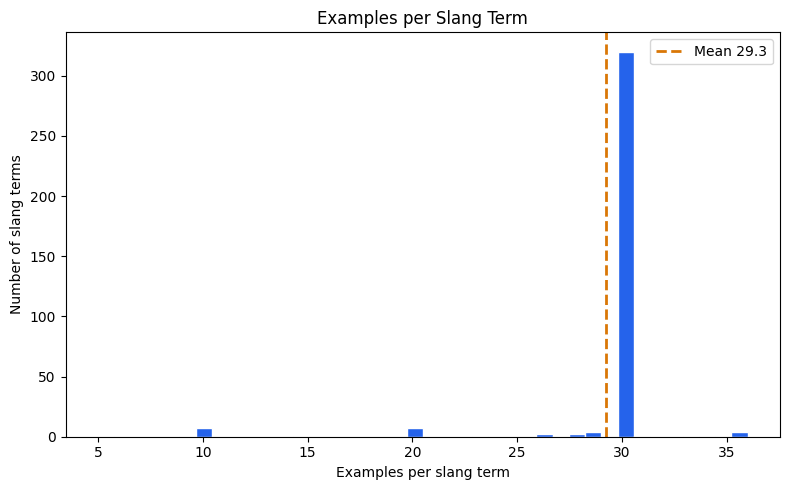

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(counts.values, bins=40, color='#2563EB', edgecolor='white')
ax.axvline(counts.mean(), color='#D97706', linestyle='--', linewidth=2,
           label=f'Mean {counts.mean():.1f}')
ax.set_xlabel('Examples per slang term')
ax.set_ylabel('Number of slang terms')
ax.set_title('Examples per Slang Term')
ax.legend()
fig.tight_layout()
fig.savefig('images/eda_examples_per_slang.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 토큰 길이 분포 → `max_seq_length` 근거

각 대화(user + assistant)를 Qwen2.5 토크나이저로 인코딩한 길이를 측정합니다.
대부분의 샘플이 512 토큰 이내라면 `max_seq_length=512`가 충분하다는 근거가 됩니다.

In [7]:
tok = AutoTokenizer.from_pretrained(MODEL_ID)

def chat_token_len(q, a):
    messages = [
        {'role': 'user', 'content': q},
        {'role': 'assistant', 'content': a},
    ]
    text = tok.apply_chat_template(messages, tokenize=False)
    return len(tok(text, add_special_tokens=False)['input_ids'])

lengths = np.array([chat_token_len(q, a) for q, a in zip(df['question'], df['answer'])])

print('=== 토큰 길이 요약 ===')
print(f'평균   : {lengths.mean():.1f}')
print(f'중앙값 : {np.median(lengths):.0f}')
print(f'95%    : {np.percentile(lengths, 95):.0f}')
print(f'99%    : {np.percentile(lengths, 99):.0f}')
print(f'최대   : {lengths.max()}')

within_512 = (lengths <= 512).mean() * 100
print(f'\n→ 512 토큰 이내 샘플 비율: {within_512:.2f}%')

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

=== 토큰 길이 요약 ===
평균   : 92.5
중앙값 : 89
95%    : 130
99%    : 158
최대   : 214

→ 512 토큰 이내 샘플 비율: 100.00%


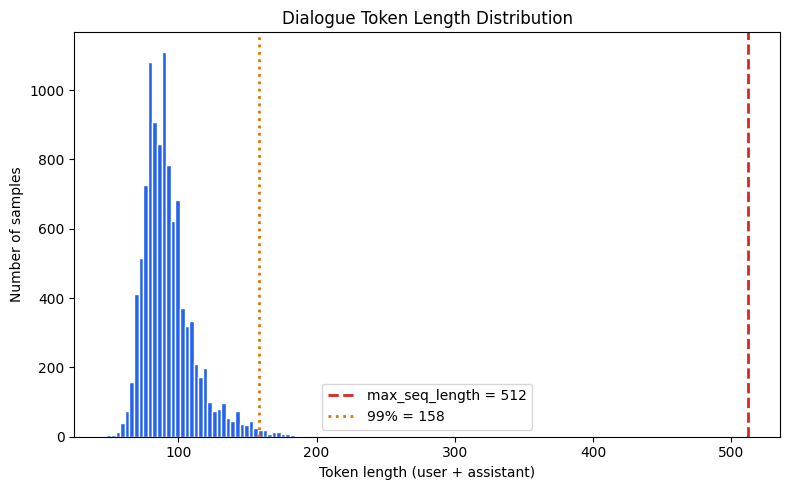

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(lengths, bins=50, color='#2563EB', edgecolor='white')
ax.axvline(512, color='#DC2626', linestyle='--', linewidth=2, label='max_seq_length = 512')
ax.axvline(np.percentile(lengths, 99), color='#D97706', linestyle=':', linewidth=2,
           label=f'99% = {np.percentile(lengths, 99):.0f}')
ax.set_xlabel('Token length (user + assistant)')
ax.set_ylabel('Number of samples')
ax.set_title('Dialogue Token Length Distribution')
ax.legend()
fig.tight_layout()
fig.savefig('images/eda_token_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 정리

위에서 출력된 실제 수치를 README II장의 🔴 표시 부분에 채워 넣으세요.

- 신조어별 예시 수: 최다 / 최소 / 중앙값
- 토큰 길이: 99% 분위수, 512 이내 비율 → `max_seq_length=512` 정당화
- 생성된 그래프 2개(`images/eda_examples_per_slang.png`, `images/eda_token_length.png`)를 repo에 커밋